<a href="https://colab.research.google.com/github/AditiSinghal28/Machine-Learning-Projects/blob/ml/MNIST_Digit_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPORTING THE DEPENDENCIES

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
import tensorflow as tf
tf.random.set_seed(3)
from tensorflow import keras
from keras.datasets import mnist
from tensorflow.math import confusion_matrix

LOADING THE MNIST DATASET FROM KERAS

In [3]:
(X_train, Y_train), (X_test, Y_test) = mnist.load_data() #the mnist data set is already split into training and testing data

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
type(X_train)

numpy.ndarray

In [5]:
#shape of the np arrays
X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [8]:
#60000 images and 28*28 pixels
#grayscale image - 1 channel

In [9]:
# printing the 10th image from xtrain
print(X_train[9])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0 189 190   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0 143 247 153   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0 136 247 242  86   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0 192 252 187   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0  62 185  18   

In [10]:
X_train[9].shape

(28, 28)

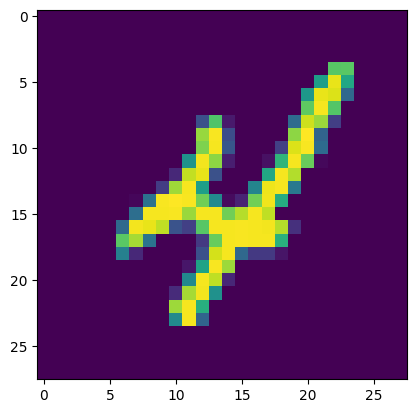

4


In [11]:
# displaying the image
plt.imshow(X_train[9])
plt.show()

print(Y_train[9])

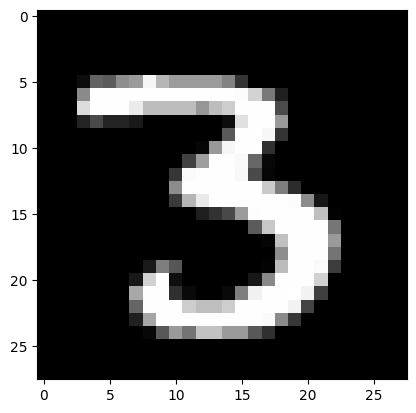

In [12]:
plt.imshow(X_train[12], cmap = 'grey')
plt.show()

IMAGE LABELS

In [13]:
print(Y_train.shape, Y_test.shape)

(60000,) (10000,)


In [14]:
#unique values in ytrain
print(np.unique(Y_train))

#unique values in ytest
print(np.unique(Y_test))

[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]


we can use the labels as it is or we can apply one hot encoding

all the images have the same dimensions so we dont need to resize them to a common dimension

In [15]:
#scaling the values
X_train = X_train/255
X_test = X_test/255

In [16]:
print(X_train[9])

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    

BUILDING THE NEURAL NETWORK

In [21]:
# setting up the layers of the neural network

model = keras.Sequential([
    keras.layers.Flatten(input_shape = (28,28)),
    keras.layers.Dense(50, activation = 'relu'),
    keras.layers.Dense(50, activation = 'relu'),
    keras.layers.Dense(10, activation = 'sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [22]:
# compiling the neural network
model.compile(optimizer = 'adam',
              loss = 'sparse_categorical_crossentropy',
              metrics = ['accuracy'])

In [23]:
#training the neural network
model.fit(X_train, Y_train, epochs = 10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8533 - loss: 0.5081
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9535 - loss: 0.1568
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9670 - loss: 0.1112
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9737 - loss: 0.0872
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9786 - loss: 0.0701
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9823 - loss: 0.0563
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9850 - loss: 0.0485
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9875 - loss: 0.0405
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9894 - loss: 0.0347
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9896 - loss: 0.0319


the training data accuracy is 98.9%

ACCURACY ON TEST DATA

In [24]:
loss,accuracy = model.evaluate(X_test, Y_test)
print(accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9666 - loss: 0.1355
0.9686999917030334


test data accuracy - 96.8%

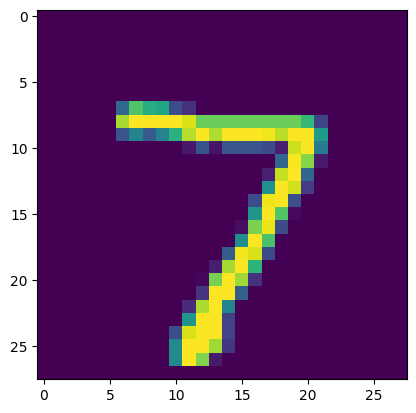

In [25]:
# first data point in xtest
plt.imshow(X_test[0])
plt.show()

In [26]:
print(Y_test[0])

7


In [27]:
Y_pred = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [28]:
print(Y_pred.shape)

(10000, 10)


In [29]:
print(Y_pred[0])

[1.0732868e-03 7.8605656e-03 9.2035025e-01 9.9882799e-01 7.0533446e-05
 1.2675806e-05 1.2568015e-10 1.0000000e+00 2.7432095e-02 9.9865347e-01]


model.predict() gives the prediction prob of each class (0-9)

In [30]:
#converting the prediction probability to class labels
label_for_first_img = np.argmax(Y_pred[0])
print(label_for_first_img)

7


In [31]:
# converting the pred prob into class labels for all test data points
Y_pred_labels = [np.argmax(i) for i in Y_pred]
print(Y_pred_labels)

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4), np.int64(1), np.int64(4), np.int64(9), np.int64(5), np.int64(9), np.int64(0), np.int64(6), np.int64(9), np.int64(0), np.int64(1), np.int64(5), np.int64(9), np.int64(7), np.int64(3), np.int64(4), np.int64(9), np.int64(6), np.int64(6), np.int64(5), np.int64(4), np.int64(0), np.int64(7), np.int64(4), np.int64(0), np.int64(1), np.int64(3), np.int64(1), np.int64(3), np.int64(4), np.int64(7), np.int64(2), np.int64(7), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(7), np.int64(4), np.int64(2), np.int64(3), np.int64(5), np.int64(1), np.int64(2), np.int64(4), np.int64(4), np.int64(6), np.int64(3), np.int64(5), np.int64(5), np.int64(6), np.int64(0), np.int64(4), np.int64(1), np.int64(9), np.int64(5), np.int64(7), np.int64(8), np.int64(9), np.int64(3), np.int64(7), np.int64(4), np.int64(6), np.int64(4), np.int64(3), np.int64(0), np.int64(7), np.int64(0), np.int64(2), np.int64(9), np.int64(1), np.int64(7), np.int64(3)

Y_test --> true labels


Y_pred_labels = predicted labels

**CONFUSION MATRIX**

In [32]:
conf_mat = confusion_matrix(Y_test, Y_pred_labels)
print(conf_mat)


tf.Tensor(
[[ 963    0    2    1    1    2    2    2    3    4]
 [   0 1106    4    2    0    1    5    8    6    3]
 [   7    0  995    9    2    2    2    9    5    1]
 [   0    0    5  983    0    5    1    6    4    6]
 [   0    0    3    0  955    0    5    2    1   16]
 [   2    0    0   11    3  851    7    1    5   12]
 [   3    2    3    1    4    8  935    0    1    1]
 [   0    0   10    3    1    1    0  997    4   12]
 [   7    0    2   17    3    8    1    4  921   11]
 [   1    1    1    5    8    2    0    6    4  981]], shape=(10, 10), dtype=int32)


Text(0.5, 47.7222222222222, 'Predicted labels')

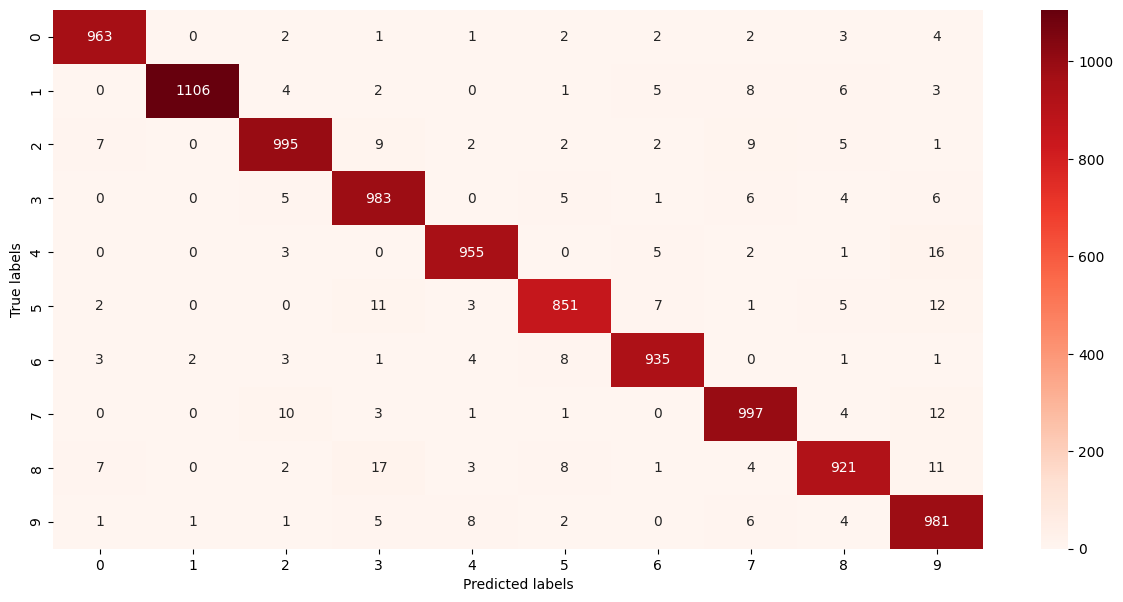

In [39]:
plt.figure(figsize = (15,7))
sns.heatmap(conf_mat, annot = True, fmt = 'd', cmap = 'Reds')
plt.ylabel('True labels')
plt.xlabel('Predicted labels')


BUILDING A PREDICTIVE SYSTEM

In [40]:
input_image_path = '/content/images.png'

input_image = cv2.imread(input_image_path)

In [41]:
type(input_image)

numpy.ndarray

In [42]:
input_image.shape

(176, 176, 3)

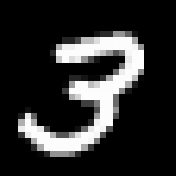

In [43]:
cv2_imshow(input_image)

In [44]:
grayscale = cv2.cvtColor(input_image, cv2.COLOR_BGR2GRAY)

In [45]:
grayscale.shape

(176, 176)

In [46]:
input_image_resize = cv2.resize(grayscale, (28,28))

In [47]:
input_image_resize.shape

(28, 28)

In [48]:
cv2_imshow(input_image_resize)

In [49]:
input_image_resize = input_image_resize/255

In [50]:
image_reshaped = np.reshape(input_image_resize, [1,28,28])

In [51]:
input_prediction = model.predict(image_reshaped)
print(input_prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
[[1.9175121e-07 4.0722151e-10 2.3229449e-04 1.0000000e+00 3.6232113e-12
  3.0346311e-04 2.9738976e-17 7.7647528e-06 9.5423096e-01 9.9999851e-01]]


In [52]:
input_pred_label = np.argmax(input_prediction)
print(input_pred_label)

3
